# Multiclass IMV — results across the three examples

Everything the three `src/empirical/multi_imv/*.ipynb` notebooks produced, gathered in one place: for each example one metrics table and one 2×3 figure — pairwise IMV heatmaps on the top row, one-vs-rest IMV bars on the bottom, one column per estimator.

Nothing is recomputed here. The tables and matrices are read back from `output/examples/multi_imv/` and the artefact cache, so this notebook is cheap to re-run and cannot disagree with the examples it summarises. Run the three example notebooks first if a file is missing.

The figure style — panel size, palette, weights, sizes, edge colour — comes from `src/empirical/plotter/shared_style.py`, so any other notebook can import it and produce panels that sit beside these without retouching.

In [1]:
import os, sys
from pathlib import Path

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "requirements.txt").is_file()
    and (path / "src" / "empirical" / "plotter" / "figure_utils.py").is_file()
)

def relative_path(path, *, start=None):
    """Display-only path, anchored so no absolute home path reaches an output."""
    anchor = Path(start) if start is not None else PROJECT_ROOT
    try:
        relative = os.path.relpath(Path(path).expanduser().resolve(),
                                   start=Path(anchor).expanduser().resolve())
    except ValueError:  # different Windows drives cannot be relativized
        relative = Path(path).name
    return Path(relative).as_posix()

# The style package lives under src/ so every notebook, wherever it sits,
# imports the same one.
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
from empirical.plotter import shared_style
from empirical.plotter.figure_utils import (
    figure_directory, save_publication_figure as save_figure,
)

CACHE = Path(os.environ.get("IMV_CACHE_HOME", Path.home() / ".cache" / "imv"))
ARTIFACTS = Path(os.environ.get("IMV_ARTIFACT_CACHE", CACHE / "notebook_artifacts"))
OUTPUT = PROJECT_ROOT / "output" / "examples" / "multi_imv"
OUTPUT.mkdir(parents=True, exist_ok=True)
FIGURES = figure_directory(PROJECT_ROOT)
FIGURES.mkdir(parents=True, exist_ok=True)

MODEL_NAMES = ("logistic_regression", "xgboost", "lightgbm")
MODEL_LABELS = {"logistic_regression": "Logistic regression",
                "xgboost": "XGBoost", "lightgbm": "LightGBM"}
# Panels are referred to by letter (column) and row in the caption.
PANEL_LETTERS = "abcdefgh"
EXAMPLES = {"car_evaluation": "Car Evaluation", "dry_bean": "Dry Bean",
            "nursery": "Nursery"}
GLOBAL_LABELS = {"f1_weighted": "F1 Score", "roc_auc_ovr_weighted": "AUC-ROC",
                 "log_loss": "Log Loss", "hamming_loss": "Hamming Loss",
                 "cohens_kappa": "Cohen's Kappa", "jaccard_weighted": "Jaccard"}
# Rates keep the percentage reading the example notebooks give them; IMV, Brier
# loss and log loss stay on their own scale.
PERCENT_METRICS = {"f1_weighted", "roc_auc_ovr_weighted", "cohens_kappa",
                   "jaccard_weighted"}

shared_style.apply()
print(f"style: {shared_style.PALETTE} palette, "
      f"{shared_style.PANEL_WIDTH}×{shared_style.PANEL_HEIGHT}in panels, "
      f"base font {shared_style.BASE_FONT_SIZE}pt")
print(f"reading from {relative_path(OUTPUT)}/ and {relative_path(ARTIFACTS)}/")

style: imv palette, 5.4×4.6in panels, base font 11pt
reading from output/examples/multi_imv/ and ../../.cache/imv/notebook_artifacts/


## 1. Load what the examples wrote

Each file is looked up under `output/examples/multi_imv/` first and in the artefact cache second, so a checkout that ships only `output/` still renders everything except the pairwise matrices, which live in the cache alone.

The per-example tables are then concatenated into four cross-example CSVs, which is the one thing this notebook adds rather than repeats.

In [2]:
def write_csv_atomic(table, path, *, index=False):
    """Replace a CSV only after its complete contents reach the same directory."""
    temporary = path.with_name(f".{path.name}.{os.getpid()}.tmp")
    try:
        table.to_csv(temporary, index=index)
        os.replace(temporary, path)
    finally:
        temporary.unlink(missing_ok=True)

def read_result(dataset, filename, **read_kwargs):
    """Read one artefact, preferring the published copy under output/."""
    candidates = [OUTPUT / filename,
                  ARTIFACTS / f"multi_imv_{dataset}" / "results" / filename]
    for path in candidates:
        if path.is_file():
            return pd.read_csv(path, **read_kwargs)
    raise FileNotFoundError(
        f"{filename} is missing; run src/empirical/multi_imv/multi_imv_{dataset}.ipynb "
        f"first (looked in {', '.join(relative_path(path) for path in candidates)})")

def load_example(dataset, title):
    """One example's tables, matrices and class names, as the figures need them."""
    class_summary = read_result(dataset, f"{dataset}_class_metrics_summary.csv")
    class_names = (class_summary[["class", "class_name"]].drop_duplicates()
                   .sort_values("class")["class_name"].tolist())
    by_seed = read_result(dataset, f"{dataset}_one_vs_rest_by_seed.csv")
    ova_summary = (by_seed.groupby(["model", "class"])["one_vs_rest_imv"]
                   .agg(["mean", "std"]).reset_index())
    pairwise = {name: read_result(dataset, f"{dataset}_pairwise_imv_{name}.csv",
                                  index_col=0)
                for name in MODEL_NAMES}
    missing = sorted(set(MODEL_NAMES) - set(ova_summary["model"]))
    if missing:
        raise ValueError(f"{dataset}: no one-vs-rest results for {missing}")
    return {
        "dataset": dataset, "title": title, "class_names": class_names,
        "n_seeds": int(by_seed["seed"].nunique()),
        "class_summary": class_summary, "ova_summary": ova_summary,
        "pairwise": pairwise,
        "table": read_result(dataset, f"{dataset}_metrics_table.csv").set_index("Methods"),
        "global_summary": read_result(dataset, f"{dataset}_global_metrics_summary.csv"),
    }

results = {dataset: load_example(dataset, title) for dataset, title in EXAMPLES.items()}
for result in results.values():
    print(f"{result['title']:<15} {len(result['class_names'])} classes, "
          f"{result['n_seeds']} seeds, {len(result['pairwise'])} models: "
          f"{', '.join(result['class_names'])}")

def tagged(result, table):
    """A copy of `table` carrying the example it came from as its first columns."""
    tagged_table = table.copy()
    tagged_table.insert(0, "dataset", result["title"])
    tagged_table.insert(0, "example", f"multi_imv_{result['dataset']}")
    return tagged_table

combined_class = pd.concat(
    [tagged(result, result["class_summary"]) for result in results.values()],
    ignore_index=True)
combined_global = pd.concat(
    [tagged(result, result["global_summary"]) for result in results.values()],
    ignore_index=True)
combined_ova = pd.concat(
    [tagged(result, result["ova_summary"].assign(
        class_name=lambda part: [result["class_names"][int(value)]
                                 for value in part["class"]]))
     for result in results.values()],
    ignore_index=True).rename(columns={"mean": "one_vs_rest_imv_mean",
                                       "std": "one_vs_rest_imv_std"})
# The matrices go out long rather than as three square blocks per example, so a
# reader can filter to one pair of classes across every example and estimator.
combined_pairwise = pd.concat(
    [tagged(result, pd.DataFrame(
        [{"model": name, "class_i": row, "class_j": column,
          "class_i_name": result["class_names"][int(row)],
          "class_j_name": result["class_names"][int(column)],
          "pairwise_imv": matrix.loc[row, column]}
         for name, matrix in result["pairwise"].items()
         for row in matrix.index for column in matrix.columns]))
     for result in results.values()],
    ignore_index=True)

for table, name in ((combined_class, "class_metrics_summary"),
                    (combined_global, "global_metrics_summary"),
                    (combined_ova, "one_vs_rest_summary"),
                    (combined_pairwise, "pairwise_imv")):
    write_csv_atomic(table, OUTPUT / f"multi_imv_results__{name}.csv")
print(f"wrote four cross-example tables to {relative_path(OUTPUT)}/")
combined_global

Car Evaluation  4 classes, 10 seeds, 3 models: unacc, acc, good, vgood
Dry Bean        7 classes, 10 seeds, 3 models: BARBUNYA, BOMBAY, CALI, DERMASON, HOROZ, SEKER, SIRA
Nursery         3 classes, 10 seeds, 3 models: not_recom, priority, spec_prior
wrote four cross-example tables to output/examples/multi_imv/


,example,dataset,model,f1_weighted_mean,f1_weighted_std,roc_auc_ovr_weighted_mean,roc_auc_ovr_weighted_std,log_loss_mean,log_loss_std,hamming_loss_mean,hamming_loss_std,cohens_kappa_mean,cohens_kappa_std,jaccard_weighted_mean,jaccard_weighted_std
0,multi_imv_car_evaluation,Car Evaluation,lightgbm,0.978878,0.001825,0.998987,0.000383,0.083345,0.002867,0.021412,0.001850,0.953815,0.003967,0.959437,0.003370
1,multi_imv_car_evaluation,Car Evaluation,logistic_regression,0.638436,0.003208,0.772946,0.001223,0.686837,0.001441,0.310243,0.002994,0.163148,0.007824,0.524194,0.003111
2,multi_imv_car_evaluation,Car Evaluation,xgboost,0.966933,0.002931,0.997136,0.000461,0.140061,0.001987,0.033449,0.002961,0.927912,0.006321,0.937598,0.005149
3,multi_imv_dry_bean,Dry Bean,lightgbm,0.927541,0.001064,0.994102,0.000059,0.196134,0.001138,0.072463,0.001074,0.912324,0.001303,0.866559,0.001825
4,multi_imv_dry_bean,Dry Bean,logistic_regression,0.924279,0.000380,0.993396,0.000028,0.214056,0.000595,0.075850,0.000383,0.908277,0.000464,0.860990,0.000632
5,multi_imv_dry_bean,Dry Bean,xgboost,0.927348,0.000824,0.994171,0.000062,0.192952,0.000931,0.072647,0.000833,0.912100,0.001012,0.866238,0.001427
6,multi_imv_nursery,Nursery,lightgbm,0.997641,0.000603,0.999986,0.000012,0.056726,0.000635,0.002359,0.000603,0.996460,0.000904,0.995299,0.001197
7,multi_imv_nursery,Nursery,logistic_regression,0.787415,0.000526,0.917658,0.000065,0.392640,0.000126,0.212510,0.000528,0.681053,0.000791,0.678735,0.000601
8,multi_imv_nursery,Nursery,xgboost,0.994031,0.000525,0.999916,0.000011,0.080378,0.000492,0.005970,0.000525,0.991043,0.000788,0.988170,0.001032


## 2. Table and figure for one example

The figure is a 2×3 grid: the top row is the pairwise IMV matrix per estimator, the bottom row the one-vs-rest IMV per class, with the spread across seeds as the error bar.

The two rows are **not on the same scale** and must not be read against each other. The one-vs-rest null model already knows the class base rate, so it starts above chance; pairwise renormalisation leaves its null at the 0.5 chance floor. Identical predictive power therefore reads lower on the bottom row. Within the top row the three matrices share one colour scale, so estimators can be compared cell by cell.

In [3]:
def format_global_metrics(summary):
    """The global metrics of one example as one line per estimator."""
    indexed = summary.set_index("model")
    lines = []
    for name in MODEL_NAMES:
        row = indexed.loc[name]
        cells = []
        for metric, label in GLOBAL_LABELS.items():
            scale = 100 if metric in PERCENT_METRICS else 1
            deviation = row[f"{metric}_std"]
            cells.append(f"{label}: {scale * row[f'{metric}_mean']:.2f}"
                         f"±{scale * (0.0 if pd.isna(deviation) else deviation):.2f}")
        lines.append(f"{MODEL_LABELS[name]}: " + "; ".join(cells))
    return "\n".join(lines)

def example_figure(result):
    """Pairwise IMV heatmaps over one-vs-rest IMV bars, one column per estimator.

    The panels sit on an explicit gridspec rather than on the constrained layout
    engine. The two rows carry different y labels — class names above, numbers
    below — and a decoration-aware layout sizes their columns to fit those, so
    the heatmap would not end up over the bar chart it belongs to. Fixed cells
    let the labels overflow into the margin instead, and the columns line up.
    """
    class_names = result["class_names"]
    n_classes = len(class_names)
    figure = plt.figure(figsize=shared_style.figure_size(2, len(MODEL_NAMES)))
    # The column gap has to clear a full set of class names, since every panel
    # keeps its own y labels.
    grid = figure.add_gridspec(
        2, len(MODEL_NAMES), height_ratios=[1, 0.85],
        left=0.065, right=0.925, bottom=0.13, top=0.88, wspace=0.42, hspace=0.52,
    )
    # One colour scale and one bar ceiling across the row, or the three panels
    # would each be drawn to their own maximum and invite a false comparison.
    matrices = [matrix.to_numpy(dtype=float) for matrix in result["pairwise"].values()]
    scale_top = max(float(np.nanmax(matrix)) for matrix in matrices)
    # IMV dips below zero where the enhanced model loses to the null on a pair;
    # a floor at zero would paint those cells as ties.
    scale_bottom = min(0.0, min(float(np.nanmin(matrix)) for matrix in matrices))
    bar_top = float((result["ova_summary"]["mean"]
                     + result["ova_summary"]["std"].fillna(0)).max())
    heatmap_style = shared_style.heatmap_style(n_classes)
    # Cells fill the panel instead of being squared off inside it, which is what
    # keeps every heatmap exactly as wide as the bar chart beneath it.
    heatmap_style["square"] = False

    axes = np.empty((2, len(MODEL_NAMES)), dtype=object)
    for column, name in enumerate(MODEL_NAMES):
        letter = PANEL_LETTERS[column]
        heat_axis = figure.add_subplot(grid[0, column])
        bar_axis = figure.add_subplot(grid[1, column])
        axes[0, column], axes[1, column] = heat_axis, bar_axis

        sns.heatmap(result["pairwise"][name], ax=heat_axis, vmin=scale_bottom,
                    vmax=scale_top, cbar=False, **heatmap_style)
        #heat_axis.set_title(f"{letter}1. {MODEL_LABELS[name]} — pairwise IMV",
        #                    **shared_style.TITLE_KWARGS)
        heat_axis.set_xticklabels(class_names, rotation=45, ha="right")
        # Every panel keeps its own tick labels. These panels are read across as
        # much as down, and a reader should not have to count rows back to the
        # left-hand one to find out which class a cell belongs to.
        heat_axis.set_yticklabels(class_names, rotation=0)

        part = (result["ova_summary"][result["ova_summary"].model == name]
                .sort_values("class"))
        bars = bar_axis.bar(class_names, part["mean"], yerr=part["std"].fillna(0),
                            **shared_style.bar_style(n_classes))
        # The bars are close together on some examples and the error bar is
        # narrower than the line width, so each mean is also written out.
        bar_axis.bar_label(bars, labels=[f"{value:.3f}" for value in part["mean"]],
                           padding=2, fontsize=shared_style.ANNOTATION_FONT_SIZE - 1,
                           color=shared_style.TEXT_COLOR)
        bar_axis.set_title(f"{letter}2. {MODEL_LABELS[name]} — one-vs-rest IMV",
                           **shared_style.TITLE_KWARGS)
        bar_axis.set_ylim(0, bar_top * 1.22)      # headroom for the labels
        bar_axis.set_xticks(range(n_classes))
        bar_axis.set_xticklabels(class_names, rotation=45, ha="right")

    # Hung off the last heatmap rather than given a grid column of its own, so
    # it stays beside the panel it describes whatever the class count.
    colorbar = figure.colorbar(
        axes[0, 0].collections[0],
        cax=axes[0, -1].inset_axes([1.025, 0.0, 0.022, 1.0]))
    colorbar.set_label("Pairwise IMV", **shared_style.LABEL_KWARGS)
    colorbar.outline.set_visible(False)
    axes[1, 0].set_ylabel(f"One-vs-rest IMV (mean of {result['n_seeds']} seeds)",
                          **shared_style.LABEL_KWARGS)
    figure.suptitle(f"{result['title']} — multiclass IMV, mean over "
                    f"{result['n_seeds']} seeds", **shared_style.SUPTITLE_KWARGS)
    return figure

def show_example(dataset):
    """The example's metrics table, its global metrics, and its saved figure."""
    result = results[dataset]
    print(f"{result['title']}: per-class metrics, mean over {result['n_seeds']} "
          "seeds ± spread across seeds")
    display(result["table"])
    print(format_global_metrics(result["global_summary"]))
    figure = example_figure(result)
    paths = save_figure(figure, FIGURES / f"multi_imv_results__{dataset}")
    plt.show()
    plt.close(figure)
    return {file_format: relative_path(path) for file_format, path in paths.items()}

## 3. Car Evaluation

Four ordered classes, and the two rare ones (`good`, `vgood`) hold 134 of 1728 rows. Logistic regression never predicts `good` at all and catches a fifth of `vgood`; both boosted models recover them. Note the one negative cell in the logistic-regression matrix: on the `acc`/`good` pair the features leave it very slightly worse than the null model.

Car Evaluation: per-class metrics, mean over 10 seeds ± spread across seeds


,unacc,acc,good,vgood
Methods,,,,
Multi-IMV (LR),0.15±0.00,0.05±0.00,0.00±0.00,0.02±0.00
Brier Loss (LR),0.17±0.00,0.16±0.00,0.04±0.00,0.03±0.00
Accuracy (LR),72.16±0.31,74.30±0.34,96.01±0.00,95.48±0.08
Precision (LR),74.51±0.19,34.99±1.34,0.00±0.00,33.91±1.74
Recall (LR),91.58±0.33,18.23±0.78,0.00±0.00,21.23±1.21
Multi-IMV (XGB),0.40±0.00,0.25±0.00,0.03±0.00,0.04±0.00
Brier Loss (XGB),0.02±0.00,0.03±0.00,0.01±0.00,0.01±0.00
Accuracy (XGB),97.84±0.20,97.06±0.24,98.87±0.20,99.54±0.14
Precision (XGB),99.32±0.20,91.93±0.89,83.67±1.77,91.85±2.50


Logistic regression: F1 Score: 63.84±0.32; AUC-ROC: 77.29±0.12; Log Loss: 0.69±0.00; Hamming Loss: 0.31±0.00; Cohen's Kappa: 16.31±0.78; Jaccard: 52.42±0.31
XGBoost: F1 Score: 96.69±0.29; AUC-ROC: 99.71±0.05; Log Loss: 0.14±0.00; Hamming Loss: 0.03±0.00; Cohen's Kappa: 92.79±0.63; Jaccard: 93.76±0.51
LightGBM: F1 Score: 97.89±0.18; AUC-ROC: 99.90±0.04; Log Loss: 0.08±0.00; Hamming Loss: 0.02±0.00; Cohen's Kappa: 95.38±0.40; Jaccard: 95.94±0.34


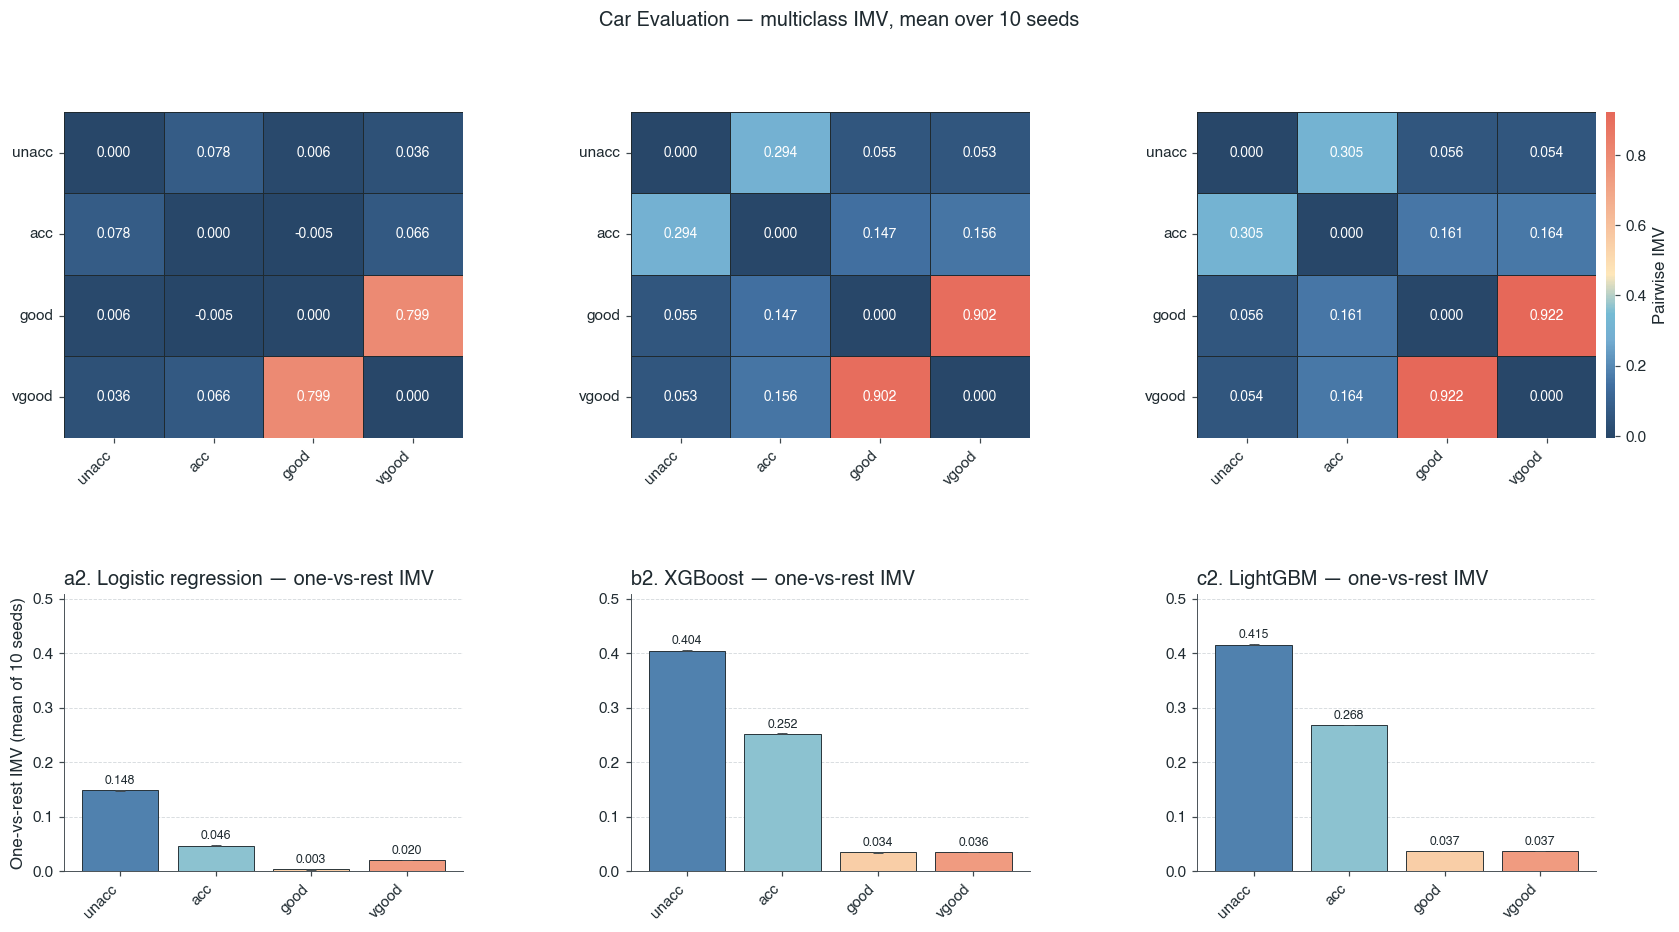

{'pdf': 'output/figures/multi_imv_results__car_evaluation.pdf'}

In [4]:
show_example("car_evaluation")

## 4. Dry Bean

Seven classes over 16 continuous morphological features. The three estimators land within a fraction of a point of each other, so the interesting variation is across classes rather than across models.

Dry Bean: per-class metrics, mean over 10 seeds ± spread across seeds


,BARBUNYA,BOMBAY,CALI,DERMASON,HOROZ,SEKER,SIRA
Methods,,,,,,,
Multi-IMV (LR),0.10±0.00,0.04±0.00,0.13±0.00,0.32±0.00,0.16±0.00,0.17±0.00,0.21±0.00
Brier Loss (LR),0.01±0.00,0.00±0.00,0.01±0.00,0.03±0.00,0.01±0.00,0.01±0.00,0.04±0.00
Accuracy (LR),98.55±0.03,100.00±0.00,98.53±0.01,95.83±0.03,98.71±0.01,98.45±0.02,94.76±0.04
Precision (LR),94.22±0.13,100.00±0.00,93.41±0.10,92.28±0.06,95.47±0.10,94.93±0.10,85.61±0.12
Recall (LR),90.63±0.22,99.96±0.08,94.36±0.06,91.66±0.06,95.41±0.06,94.68±0.08,87.69±0.12
Multi-IMV (XGB),0.10±0.00,0.04±0.00,0.13±0.00,0.33±0.00,0.16±0.00,0.17±0.00,0.21±0.00
Brier Loss (XGB),0.01±0.00,0.00±0.00,0.01±0.00,0.03±0.00,0.01±0.00,0.01±0.00,0.03±0.00
Accuracy (XGB),98.73±0.06,99.98±0.01,98.65±0.05,95.75±0.07,98.76±0.03,98.57±0.04,95.04±0.07
Precision (XGB),94.62±0.40,99.64±0.11,94.12±0.29,90.94±0.17,95.95±0.15,95.49±0.19,87.56±0.22


Logistic regression: F1 Score: 92.43±0.04; AUC-ROC: 99.34±0.00; Log Loss: 0.21±0.00; Hamming Loss: 0.08±0.00; Cohen's Kappa: 90.83±0.05; Jaccard: 86.10±0.06
XGBoost: F1 Score: 92.73±0.08; AUC-ROC: 99.42±0.01; Log Loss: 0.19±0.00; Hamming Loss: 0.07±0.00; Cohen's Kappa: 91.21±0.10; Jaccard: 86.62±0.14
LightGBM: F1 Score: 92.75±0.11; AUC-ROC: 99.41±0.01; Log Loss: 0.20±0.00; Hamming Loss: 0.07±0.00; Cohen's Kappa: 91.23±0.13; Jaccard: 86.66±0.18


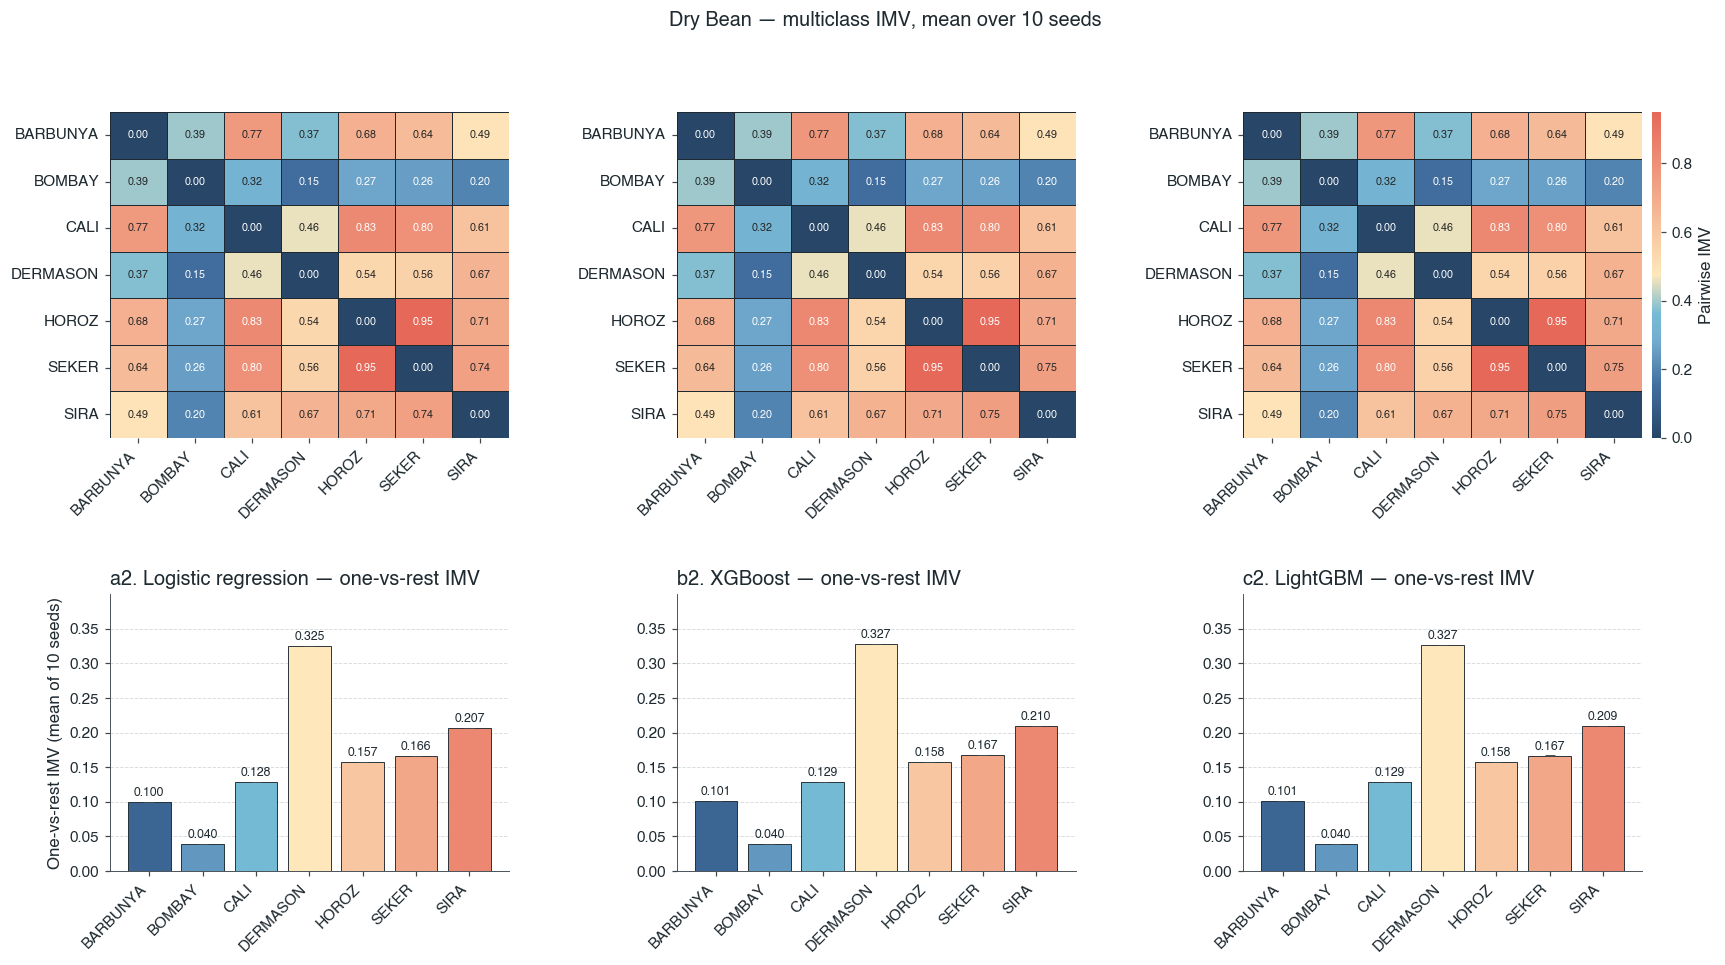

{'pdf': 'output/figures/multi_imv_results__dry_bean.pdf'}

In [5]:
show_example("dry_bean")

## 5. Nursery

Three classes, after dropping the two negligible ones as the original analysis did. `not_recom` is separable by a single feature, which is why every estimator resolves it exactly and the interest sits in the `priority`/`spec_prior` pair.

Nursery: per-class metrics, mean over 10 seeds ± spread across seeds


,not_recom,priority,spec_prior
Methods,,,
Multi-IMV (LR),0.52±0.00,0.31±0.00,0.28±0.00
Brier Loss (LR),0.00±0.00,0.13±0.00,0.13±0.00
Accuracy (LR),100.00±0.00,78.75±0.05,78.75±0.05
Precision (LR),100.00±0.00,68.20±0.07,67.16±0.10
Recall (LR),100.00±0.00,69.48±0.12,65.82±0.10
Multi-IMV (XGB),0.52±0.00,0.49±0.00,0.45±0.00
Brier Loss (XGB),0.00±0.00,0.02±0.00,0.02±0.00
Accuracy (XGB),100.00±0.00,99.40±0.05,99.40±0.05
Precision (XGB),100.00±0.00,99.92±0.03,98.24±0.16


Logistic regression: F1 Score: 78.74±0.05; AUC-ROC: 91.77±0.01; Log Loss: 0.39±0.00; Hamming Loss: 0.21±0.00; Cohen's Kappa: 68.11±0.08; Jaccard: 67.87±0.06
XGBoost: F1 Score: 99.40±0.05; AUC-ROC: 99.99±0.00; Log Loss: 0.08±0.00; Hamming Loss: 0.01±0.00; Cohen's Kappa: 99.10±0.08; Jaccard: 98.82±0.10
LightGBM: F1 Score: 99.76±0.06; AUC-ROC: 100.00±0.00; Log Loss: 0.06±0.00; Hamming Loss: 0.00±0.00; Cohen's Kappa: 99.65±0.09; Jaccard: 99.53±0.12


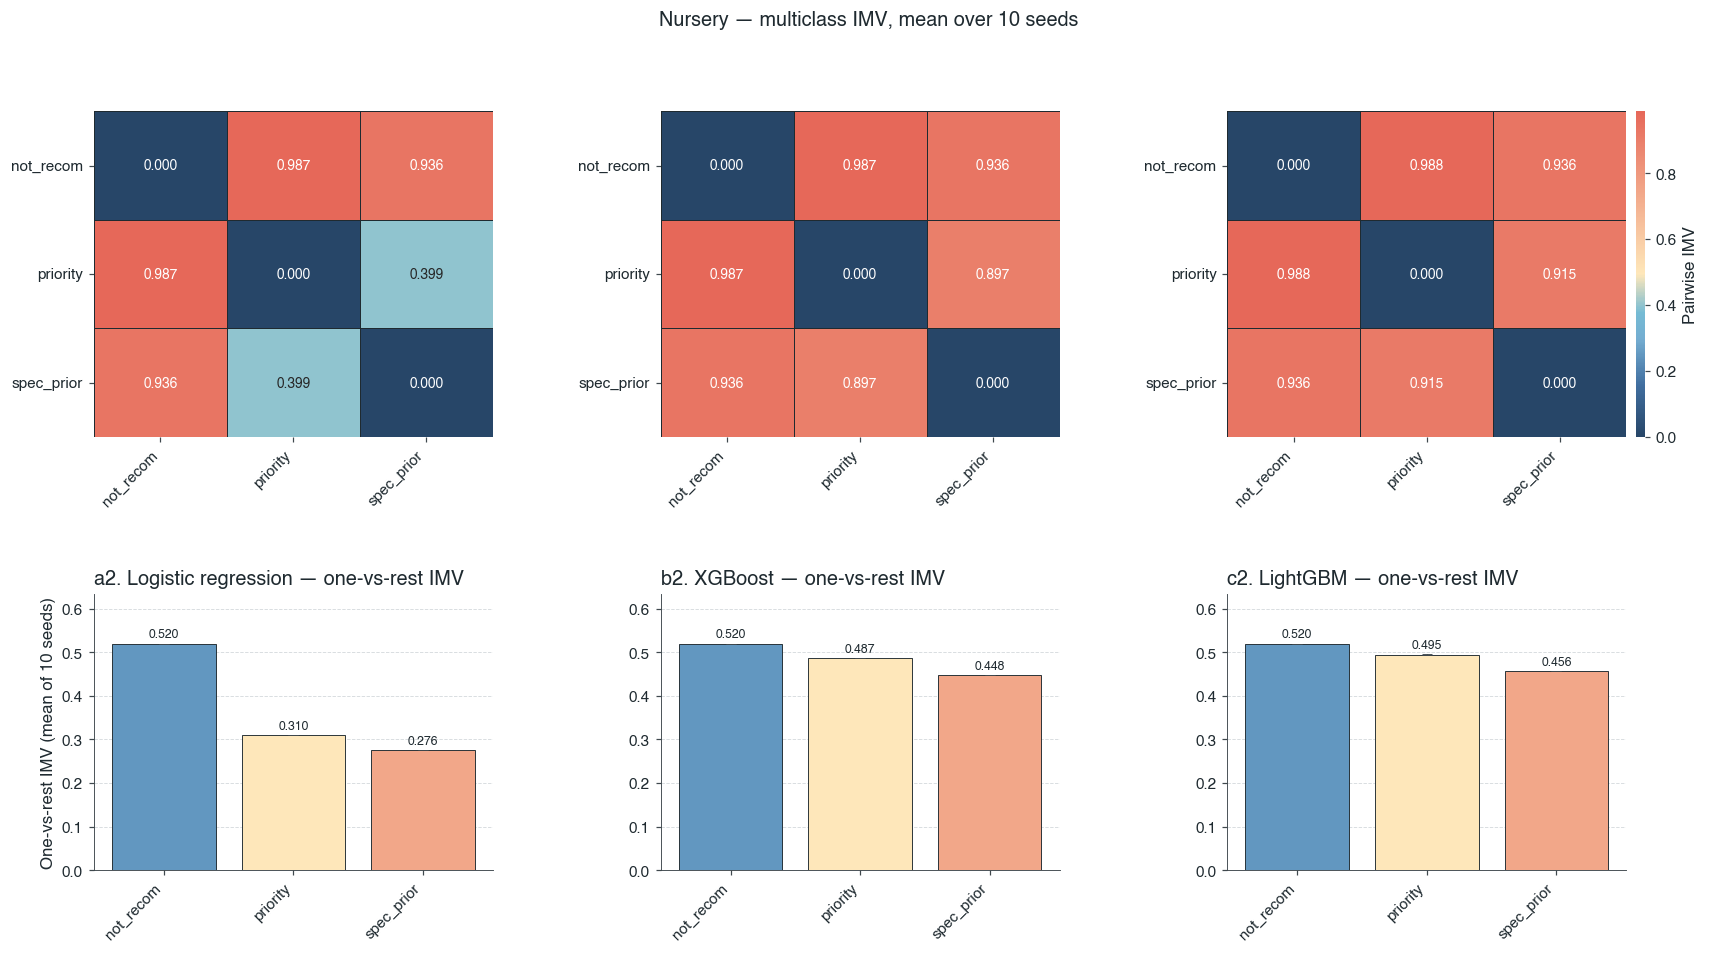

{'pdf': 'output/figures/multi_imv_results__nursery.pdf'}

In [6]:
show_example("nursery")

## 6. LaTeX tables

One `table*` environment per example, written to `output/tables/multi_imv_<dataset>.tex` as a complete float ready for `\input`, in the layout the paper already uses: booktabs rules, zebra rows, the Multi-IMV rows in bold, and the global metrics in a `\caption*` below the tabular.

The preamble needs `booktabs`, `xcolor` loaded with the `table` option (for `\rowcolor`), `graphicx` (for `\resizebox`) and `caption` (for `\caption*`).

The numbers are the same ones the tables above display, formatted from the per-seed summaries rather than re-parsed from the printed strings. Two things differ from the version of this table in the current draft: the caption states this protocol — ten seeds over five folds, mean and spread across seeds — and the accuracy rows carry the one-vs-rest accuracy of each class rather than repeating precision.

In [7]:
NOTEBOOK_PATH = "src/empirical/plotter/multi_imv_results.ipynb"
TABLES = PROJECT_ROOT / "output" / "tables"
TABLES.mkdir(parents=True, exist_ok=True)

N_SPLITS = 5                  # the fold count the three example notebooks run
ROW_COLOR = "gray!15"
TABLE_WIDTH = r"0.85\textwidth"
MODEL_SHORT = {"logistic_regression": "LR", "xgboost": "XGB", "lightgbm": "LGBM"}
CLASS_METRIC_LABELS = {"multi_imv": "Multi-IMV", "brier_loss": "Brier Loss",
                       "accuracy": "Accuracy", "precision": "Precision",
                       "recall": "Recall"}
CLASS_PERCENT_METRICS = {"accuracy", "precision", "recall"}
# Class headings as the paper prints them; anything unlisted is title-cased.
CLASS_DISPLAY_NAMES = {
    "car_evaluation": {"unacc": "Unacc", "acc": "Acc", "good": "Good",
                       "vgood": "Very good"},
    "nursery": {"not_recom": "Not recom.", "priority": "Priority",
                "spec_prior": "Spec. prior"},
}

def write_text_atomic(text, path):
    """Replace a file only after its complete contents reach the same directory."""
    temporary = path.with_name(f".{path.name}.{os.getpid()}.tmp")
    try:
        temporary.write_text(text)
        os.replace(temporary, path)
    finally:
        temporary.unlink(missing_ok=True)

def escape_latex(text):
    """Escape the characters that actually occur in these names."""
    replacements = {"\\": r"\textbackslash{}", "&": r"\&", "%": r"\%", "$": r"\$",
                    "#": r"\#", "_": r"\_", "{": r"\{", "}": r"\}",
                    "~": r"\textasciitilde{}", "^": r"\textasciicircum{}"}
    return "".join(replacements.get(character, character) for character in str(text))

def class_heading(dataset, class_name):
    display = CLASS_DISPLAY_NAMES.get(dataset, {}).get(
        class_name, class_name.replace("_", " ").title())
    return escape_latex(display)

def latex_value(metric, mean, deviation, *, bold):
    scale = 100 if metric in CLASS_PERCENT_METRICS else 1
    spread = 0.0 if pd.isna(deviation) else deviation
    body = f"{scale * mean:.2f}$\\pm${scale * spread:.2f}"
    return f"\\textbf{{{body}}}" if bold else body

def latex_global_line(result, model):
    """One estimator's global metrics as the sentence under the tabular."""
    row = result["global_summary"].set_index("model").loc[model]
    cells = []
    for metric, label in GLOBAL_LABELS.items():
        scale = 100 if metric in PERCENT_METRICS else 1
        deviation = row[f"{metric}_std"]
        spread = 0.0 if pd.isna(deviation) else deviation
        cells.append(f"{label}: {scale * row[f'{metric}_mean']:.2f}"
                     f"$\\pm${scale * spread:.2f}")
    return f"Global metrics ({MODEL_SHORT[model]}): " + "; ".join(cells) + "."

def latex_table(result):
    """One example as a complete `table*` float."""
    dataset, class_names = result["dataset"], result["class_names"]
    summary = result["class_summary"].set_index(["model", "class"])
    headings = " & ".join(
        f"\\multicolumn{{1}}{{c}}{{\\bf{{{class_heading(dataset, name)}}}}}"
        for name in class_names)

    rows = []
    for model in MODEL_NAMES:
        for metric, label in CLASS_METRIC_LABELS.items():
            # Multi-IMV is the row the table is about, so it carries the weight.
            bold = metric == "multi_imv"
            heading = f"{label} ({MODEL_SHORT[model]})"
            heading = f"\\textbf{{{heading}}}" if bold else heading
            values = [latex_value(metric, summary.loc[(model, index), f"{metric}_mean"],
                                  summary.loc[(model, index), f"{metric}_std"], bold=bold)
                      for index in range(len(class_names))]
            rows.append(f"{heading} & " + " & ".join(values) + r" \\")
    # Zebra striping runs every other row and carries on across the estimator
    # blocks, so the shading never lines up with a block boundary.
    rows = [f"\\rowcolor{{{ROW_COLOR}}}{row}" if index % 2 else row
            for index, row in enumerate(rows)]

    global_block = "\n".join(
        ("" if index == 0 else r"\\") + latex_global_line(result, model)
        for index, model in enumerate(MODEL_NAMES))
    caption = (f"Results of Multi-IMV using Logistic Regression, XGBoost, and "
               f"LightGBM algorithms with the {escape_latex(result['title'])} dataset. "
               f"The results are based on {result['n_seeds']} random seeds over "
               f"{N_SPLITS}-fold cross-validation, with the mean and the standard "
               f"deviation across seeds reported. Brier Loss represents Brier Score "
               f"Loss; accuracy, precision and recall read each class one-vs-rest.")

    return "\n".join([
        f"% Generated by {NOTEBOOK_PATH}; do not edit by hand.",
        r"% Requires: \usepackage{booktabs}, \usepackage[table]{xcolor}, "
        r"\usepackage{graphicx}, \usepackage{caption}.",
        r"\begin{table*}[htbp]",
        r"\centering",
        f"\\caption{{{caption}}}",
        f"\\resizebox{{{TABLE_WIDTH}}}{{!}}{{",
        f"\\begin{{tabular}}{{l{'c' * len(class_names)}}}",
        r"\toprule",
        r"\multicolumn{1}{l}{{\bf{Methods}}} & " + headings + r"\\",
        r"\midrule",
        *rows,
        r"\bottomrule",
        r"\end{tabular}",
        "}",
        f"\\label{{tab:MultiIMV{result['title'].replace(' ', '')}}}",
        r"\caption*{\footnotesize\normalfont",
        global_block,
        "}",
        r"\end{table*}",
        "",
    ])

latex_tables = {dataset: latex_table(result) for dataset, result in results.items()}
for dataset, text in latex_tables.items():
    write_text_atomic(text, TABLES / f"multi_imv_{dataset}.tex")
    print(f"wrote {relative_path(TABLES / f'multi_imv_{dataset}.tex')}")

wrote output/tables/multi_imv_car_evaluation.tex
wrote output/tables/multi_imv_dry_bean.tex
wrote output/tables/multi_imv_nursery.tex


### The generated source

All three floats in full, for pasting straight into the manuscript. Each is also on disk at `output/tables/multi_imv_<dataset>.tex`, rewritten every time this notebook runs.

In [8]:
for dataset, text in latex_tables.items():
    print(f"% ---------- {dataset} "
          f"{'-' * max(0, 66 - len(dataset))}")
    print(text)

% ---------- car_evaluation ----------------------------------------------------
% Generated by src/empirical/plotter/multi_imv_results.ipynb; do not edit by hand.
% Requires: \usepackage{booktabs}, \usepackage[table]{xcolor}, \usepackage{graphicx}, \usepackage{caption}.
\begin{table*}[htbp]
\centering
\caption{Results of Multi-IMV using Logistic Regression, XGBoost, and LightGBM algorithms with the Car Evaluation dataset. The results are based on 10 random seeds over 5-fold cross-validation, with the mean and the standard deviation across seeds reported. Brier Loss represents Brier Score Loss; accuracy, precision and recall read each class one-vs-rest.}
\resizebox{0.85\textwidth}{!}{
\begin{tabular}{lcccc}
\toprule
\multicolumn{1}{l}{{\bf{Methods}}} & \multicolumn{1}{c}{\bf{Unacc}} & \multicolumn{1}{c}{\bf{Acc}} & \multicolumn{1}{c}{\bf{Good}} & \multicolumn{1}{c}{\bf{Very good}}\\
\midrule
\textbf{Multi-IMV (LR)} & \textbf{0.15$\pm$0.00} & \textbf{0.05$\pm$0.00} & \textbf{0.00$\pm$0.